## Preis vs. Konsum von Zigaretten in Deutschland

 Forschungsfrage: Wie hängen der Zigarettenpreis und der Pro-Kopf-Verbrauch von Zigaretten in Deutschland zusammen?

In [7]:
import pandas as pd
import sys
from pathlib import Path

projekt_ordner = Path.cwd().parent
sys.path.append(str(projekt_ordner))

from src.plot_utils import (
    plot_zwei_achsen,
    plot_scatter_trend
)

In [8]:
preis_datei = "_durchschnittlicher-zigarettenpreis-in-deutschland.xlsx"

konsum_datei = "_pro-kopf-verbrauch-von-zigaretten-in-deutschland.xlsx"


def lade_daten(datei, spaltenname):

    df = pd.read_excel(
        datei,
        sheet_name="Daten",
        header=None
    )

    df = df[[1, 2]].dropna()

    df.columns = [
        "year",
        spaltenname
    ]

    df = df[
        pd.to_numeric(
            df["year"],
            errors="coerce"
        ).notna()
    ]

    df["year"] = df["year"].astype(int)

    df[spaltenname] = pd.to_numeric(
        df[spaltenname],
        errors="coerce"
    )

    return df.dropna()

In [9]:
preis_df = lade_daten(
    preis_datei,
    "price_cent"
)

konsum_df = lade_daten(
    konsum_datei,
    "consumption_per_capita"
)

df = pd.merge(
    preis_df,
    konsum_df,
    on="year"
)

df

,year,price_cent,consumption_per_capita
0,1965,4.38,2100.0
1,1970,4.73,2500.0
2,1975,5.96,2566.0
3,1980,7.45,2549.0
4,1985,9.57,2325.0
5,1995,12.39,1967.0
6,2000,13.73,2013.0
7,2005,20.38,1360.0
8,2006,21.31,1135.0
9,2007,21.85,1112.0


In [10]:
korrelation = df["price_cent"].corr(
    df["consumption_per_capita"]
)

print(
    f"Korrelation: {korrelation:.3f}"
)

if korrelation < 0:

    print(
        "Wenn der Preis steigt, sinkt der Konsum tendenziell."
    )

else:

    print(
        "Es besteht kein negativer Zusammenhang."
    )

Korrelation: -0.939
Wenn der Preis steigt, sinkt der Konsum tendenziell.


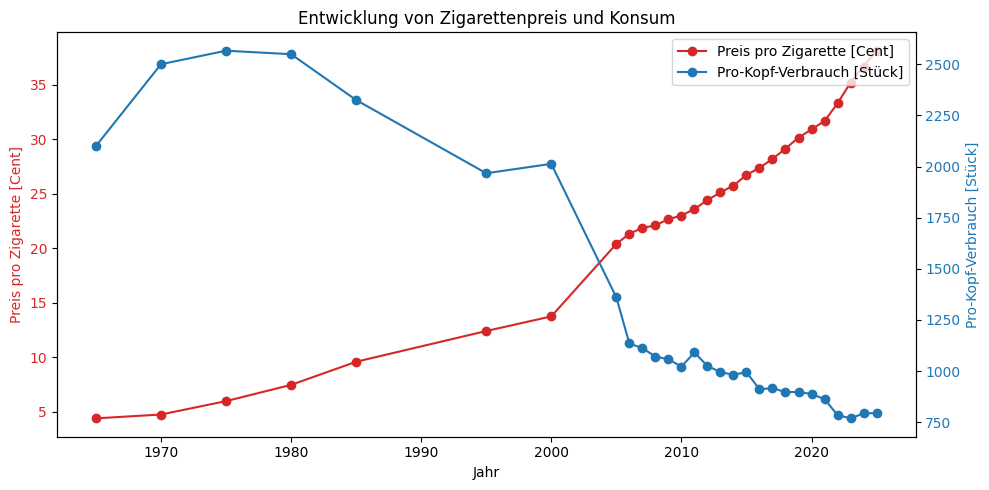

In [11]:
 #grafik 1
plot_zwei_achsen(

    df,

    "year",

    "price_cent",

    "consumption_per_capita",

    "Entwicklung von Zigarettenpreis und Konsum",

    "Jahr",

    "Preis pro Zigarette [Cent]",

    "Pro-Kopf-Verbrauch [Stück]"
)


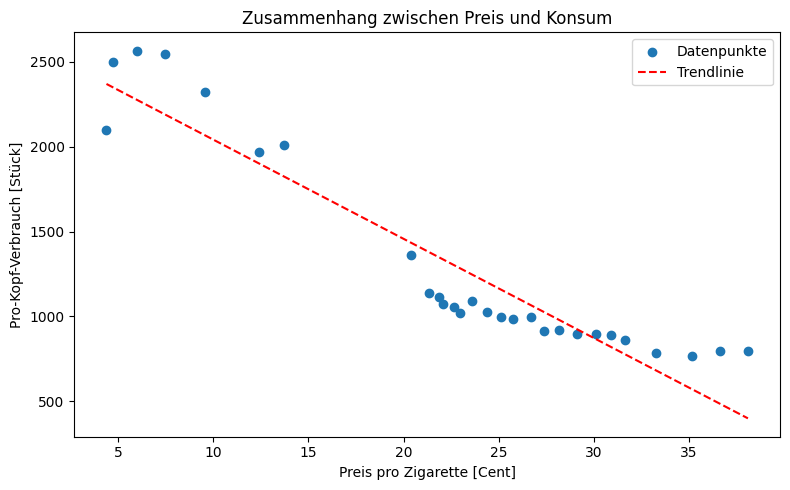

In [12]:
#grafik 2
plot_scatter_trend(

    df,

    "price_cent",

    "consumption_per_capita",

    "Zusammenhang zwischen Preis und Konsum",

    "Preis pro Zigarette [Cent]",

    "Pro-Kopf-Verbrauch [Stück]"
)

## Fazit

Die Analyse zeigt einen negativen Zusammenhang zwischen Preis und Konsum. Mit steigenden Preisen sinkt der Pro-Kopf-Verbrauch tendenziell.